In [1]:
import json
import dataclasses

import colorcet
import h5py
import matplotlib.pyplot as plt
import numpy as np

from lib.plots import set_axis, attach_colorbar
from lib.stats import fit_power_law

In [2]:
config_id = 75
filename = f"_outputs/output-{config_id}.h5"

with h5py.File(filename, "r") as store:
    config = json.loads(store["metadata/config_source"][()])
    config_used = json.loads(store["metadata/config"][()])

    production_overrides = config_used["sampling"]["phases"][-1]
    production_name = production_overrides["name"]
    phase_store = store["phases"][production_name]

    positions_history = []

    for frame_index, step_key in enumerate(phase_store[".steps"]):
        sample = phase_store[step_key]
        positions = sample["positions"][:]
        positions_history.append(positions)

    positions_history = np.array(positions_history)

frame_count = len(positions_history)

In [3]:
chain_used, = config_used["chains"]
chain_length = chain_used["length"]
default_valency = config_used["association"]["valency"]

selector_a = np.full(chain_length, False)
for feature in chain_used.get("association_features", []):
    is_a = False
    match feature:
        case {"valency": valency}:
            is_a = (valency < default_valency)

        case {"association": _} | {"dissociation": _}:
            assoc = feature.get("association", 1)
            dissoc = feature.get("dissociation", 1)
            is_a = (assoc < dissoc)

    if is_a:
        site = feature["site"]
        start = site["start"]
        end = site["end"]
        selector_a[start:end] = True

selector_b = ~selector_a

In [4]:
print("phi ", selector_a.mean())

phi  0.115


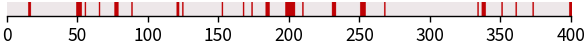

In [5]:
fig, ax = plt.subplots(figsize=(3.0, 0.3))

ax.matshow(
    selector_a[None, :],
    origin="lower",
    extent=[0, chain_length, 1, 0],
    aspect="auto",
    vmin=-1,
    vmax=1,
    cmap=colorcet.m_coolwarm,
    interpolation="kaiser",
)
set_axis(ax, "bottom")

pass

In [6]:
def drop_keys(d: dict, *arg: any) -> dict:
    return {key: value for key, value in d.items() if key not in arg}

In [7]:
def compute_rg(positions: np.ndarray) -> np.ndarray:
    centroid = positions.mean(axis=-2, keepdims=True)
    return np.sqrt((positions - centroid).var(axis=-2).sum(axis=-1))

In [8]:
sampling_config = config["sampling"]
production_config = {**drop_keys(sampling_config, "phases"), **production_overrides}

frame_interval = production_config["timestep"] * production_config["sampling_interval"]
diffusion_timescale = 1 / config["chain"]["monomer_mobility"]

In [9]:
contact_distance = 1.5
boundary_index = 200

n = positions_history.shape[1]
mean_distance_matrix = np.zeros((n, n))
mean_contact_matrix = np.zeros((n, n))
separation_scores = []
rg_samples = []

for positions in positions_history:
    distance_matrix = np.linalg.norm(
        positions[:, None, :] - positions[None, :, :],
        axis=2,
    )
    contact_matrix = (distance_matrix < contact_distance)

    mean_distance_matrix += distance_matrix
    mean_contact_matrix += contact_matrix

    D_11 = distance_matrix[:boundary_index, :boundary_index].mean()
    D_12 = distance_matrix[boundary_index:, :boundary_index].mean()
    D_22 = distance_matrix[boundary_index:, boundary_index:].mean()
    separation_score = D_12 / (D_11 + D_22)
    separation_scores.append(separation_score)

    rg = compute_rg(positions)
    rg_1 = compute_rg(positions[:boundary_index])
    rg_2 = compute_rg(positions[boundary_index:])
    rg_samples.append((rg, rg_1, rg_2))

mean_distance_matrix /= frame_count
mean_contact_matrix /= frame_count

separation_scores = np.array(separation_scores)
mean_separation_score = separation_score.mean()

rg_samples = np.array(rg_samples)
rg_separation_scores = (rg_samples[:, 1] + rg_samples[:, 2]) / rg_samples[:, 0]
mean_rg_separation_score = rg_separation_scores.mean()

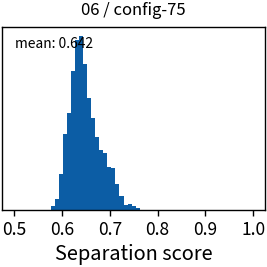

In [10]:
bins = np.linspace(0.5, 1.0, num=60)

fig, ax = plt.subplots(figsize=(1.4, 1.4))

ax.hist(separation_scores, bins=bins)

s = f"mean: {mean_separation_score:.3g}"
ax.text(0.05, 0.95, s, ha="left", va="top", fontsize="x-small", transform=ax.transAxes)

ax.set_xticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax.set_yticks([])
ax.set_xlabel("Separation score")
ax.set_title(f"06 / config-{config_id}", fontsize="small")

pass

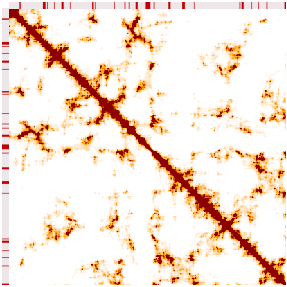

In [11]:
annot_size = 10

fig, ax = plt.subplots(figsize=(1.5, 1.5))

ax.matshow(mean_contact_matrix, vmin=0, vmax=0.1, cmap="wrr")

ax.autoscale(False)

ax.matshow(
    selector_a[:, None],
    extent=[-annot_size, 0, n, 0],
    vmin=-1, vmax=1, cmap=colorcet.m_coolwarm, interpolation="kaiser",
)
ax.matshow(
    selector_a[None, :],
    extent=[0, n, 0, -annot_size],
    vmin=-1, vmax=1, cmap=colorcet.m_coolwarm, interpolation="kaiser",
)

ax.set_xlim(-annot_size, n)
ax.set_ylim(n, -annot_size)

set_axis(ax, "none")

pass

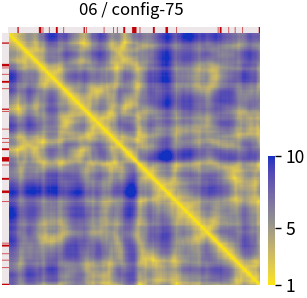

In [12]:
annot_size = 10

fig, ax = plt.subplots(figsize=(1.5, 1.5))

sm = ax.matshow(mean_distance_matrix, vmin=1, vmax=10, cmap=colorcet.m_bjy_r)

ax.autoscale(False)

ax.matshow(
    selector_a[:, None],
    extent=[-annot_size, 0, n, 0],
    vmin=-1, vmax=1, cmap=colorcet.m_coolwarm, interpolation="kaiser",
)
ax.matshow(
    selector_a[None, :],
    extent=[0, n, 0, -annot_size],
    vmin=-1, vmax=1, cmap=colorcet.m_coolwarm, interpolation="kaiser",
)

ax.set_xlim(-annot_size, n)
ax.set_ylim(n, -annot_size)

cbar = attach_colorbar(ax, sm)
cbar.outline.set_edgecolor("none")
cbar.set_ticks([1, 5, 10])

set_axis(ax, "none")

ax.set_title(f"06 / config-{config_id}", fontsize="small")

pass

In [13]:
boundary_index = 200

D_11 = mean_distance_matrix[:boundary_index, :boundary_index].mean()
D_12 = mean_distance_matrix[boundary_index:, :boundary_index].mean()
D_22 = mean_distance_matrix[boundary_index:, boundary_index:].mean()
separation_score = D_12 / (D_12 + D_22)

print(f"ss {separation_score:.4g}")

ss 0.5632
